In [2]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.data import Data
from trees.causal_tree import CT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from trees.causal_forest import CF


N = 10000
default_K = 5
default_w = 0.6
iterations = 30
s = 0.3
ws = [0.0, 0.2,  0.4,  0.6, 0.8,  1.0]
Ks = [1, 3, 5, 7, 10]

cols = ['condition', 't', 't_est', 'distance', 'T0', 'T1', 'depth', 'norm_cate',
       'score','algorithm', 'weight']

scores_over_K = pd.DataFrame(columns=cols)
scores_over_w = pd.DataFrame(columns=cols)


for exp in tqdm(range(iterations)):
    data = Data()
    data.generate(n=N, seed=exp)
    data.generate_random_condition(selectivity_threshold=s)

    ct_D = CT(data, on = "D")
    ct_D.parse_tree()

    ct_P = CT(data, on = "P")
    ct_P.parse_tree()

    cf_mse = CF(data)
    cf_mse.fit(criterion="mse", n_estimators=100)
    cf_mse.parse_forest()    

    cf_het = CF(data)
    cf_het.fit(criterion="het", n_estimators=100)
    cf_het.parse_forest()   

    for w in ws:
        for alg in [ct_D, ct_P, cf_mse, cf_het]:
            score = alg.get_topK(k=default_K, w=w, print_summaries=False)
            score['weight'] = w
            scores_over_w=pd.concat([scores_over_w, score], ignore_index=True)
    
    for K in Ks:
        for alg in [ct_D, ct_P, cf_mse, cf_het]:
            score = alg.get_topK(k=K, w=default_w, print_summaries=False)
            score['K'] = K
            scores_over_K=pd.concat([scores_over_K, score], ignore_index=True)

    cf_mse.single_tree_interpreter()
    cf_het.single_tree_interpreter()
    for w in ws:
        for alg in [cf_mse, cf_het]:
            score = alg.get_topK(k=default_K, w=w, print_summaries=False)
            score['weight'] = w
            scores_over_w=pd.concat([scores_over_w, score], ignore_index=True)

    for K in Ks:
        for alg in [cf_mse, cf_het]:
            score = alg.get_topK(k=K, w=default_w, print_summaries=False)
            score['K'] = K
            scores_over_K=pd.concat([scores_over_K, score], ignore_index=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


100%|██████████| 30/30 [1:49:24<00:00, 218.83s/it]


# Experiments with different weights

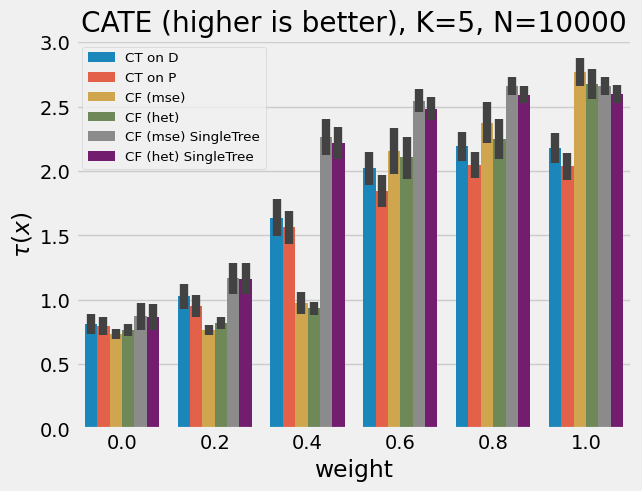

In [3]:
sns.barplot(x='weight', y='t', hue='algorithm', data=scores_over_w)
plt.title(f"CATE (higher is better), K={str(default_K)}, N={str(N)}")
plt.ylabel(r"$\tau(x)$")
plt.legend(fontsize='x-small')
plt.show()

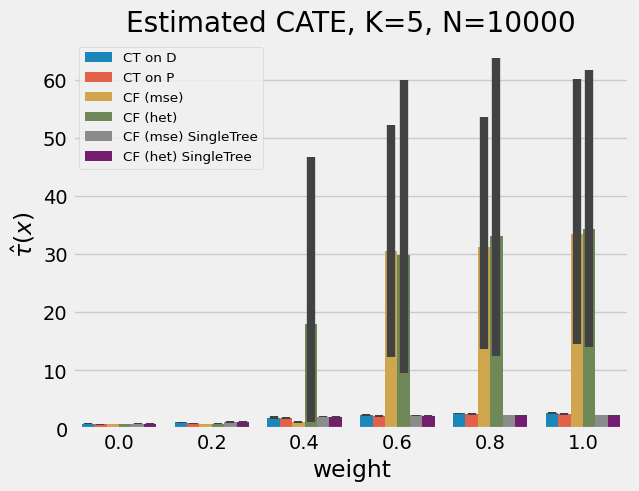

In [4]:
sns.barplot(x='weight', y='t_est', hue='algorithm', data=scores_over_w)
plt.title(fr"Estimated CATE, K={str(default_K)}, N={str(N)}")
plt.ylabel(r"$\hat{{\tau}}(x)$")
plt.legend(fontsize='x-small')
plt.show()

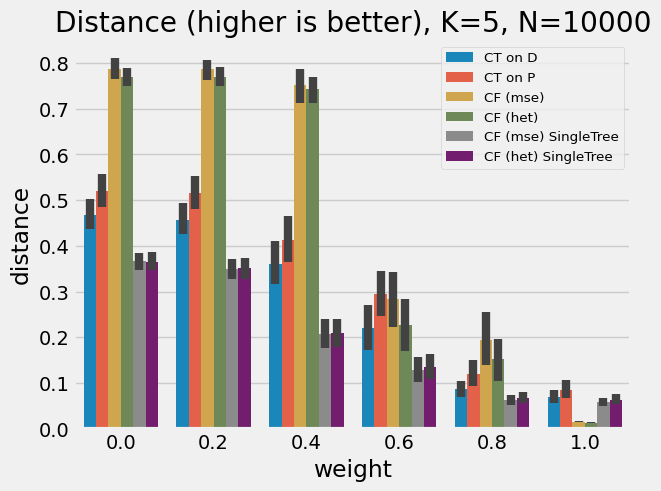

In [5]:
sns.barplot(x='weight', y='distance', hue='algorithm', data=scores_over_w)
plt.title(f"Distance (higher is better), K={str(default_K)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

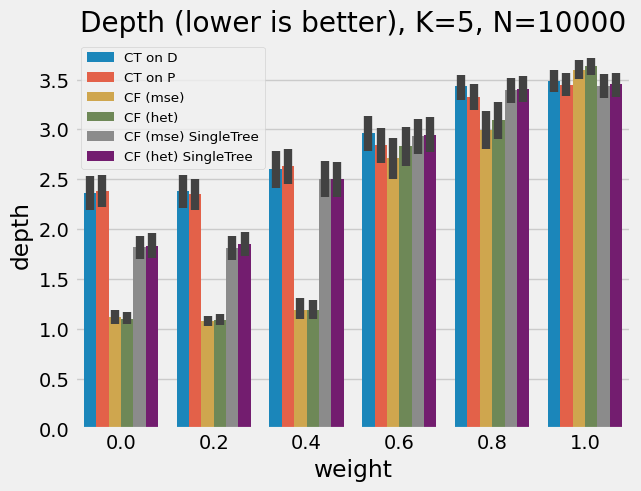

In [6]:
sns.barplot(x='weight', y='depth', hue="algorithm", data=scores_over_w)
plt.title(f"Depth (lower is better), K={str(default_K)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

In [13]:
scores_over_w

,condition,t,t_est,distance,T0,T1,depth,norm_cate,score,algorithm,weight,execution_time
0,feature_2 > -1.159,0.796,0.873,0.88,0.977846,1.850938,1,0.238264,0.880000,CT on D,0.0,NaN
1,feature_2 > -1.159 AND feature_0 > -0.089,1.541,1.659,0.47,0.846389,2.504945,2,0.452784,0.470000,CT on D,0.0,NaN
2,feature_2 > -1.159 AND feature_0 <= -0.089,0.048,0.018,0.41,1.126951,1.109136,2,0.004913,0.410000,CT on D,0.0,NaN
3,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,1.158,1.268,0.29,0.771158,2.038845,3,0.346070,0.290000,CT on D,0.0,NaN
4,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,1.048,1.162,0.27,0.671156,1.833117,4,0.317140,0.270000,CT on D,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5395,feature_0 > -0.228 AND feature_0 > 0.959 AND f...,2.893,2.198,0.06,NaN,NaN,4,1.000000,1.000000,CF (het) SingleTree,1.0,107.71
5396,feature_0 > -0.228 AND feature_0 > 0.959 AND f...,2.745,2.149,0.08,NaN,NaN,3,0.977707,0.977707,CF (het) SingleTree,1.0,107.71
5397,feature_0 > -0.228 AND feature_0 > 0.959 AND f...,2.943,2.068,0.02,NaN,NaN,4,0.940855,0.940855,CF (het) SingleTree,1.0,107.71
5398,feature_0 > -0.228 AND feature_0 > 0.959,2.350,1.938,0.17,NaN,NaN,2,0.881711,0.881711,CF (het) SingleTree,1.0,107.71


In [14]:
import pickle as pkl

with open("scores_over_w.pkl", "wb") as f:
    pkl.dump(scores_over_w, f)

# Experiments with different K

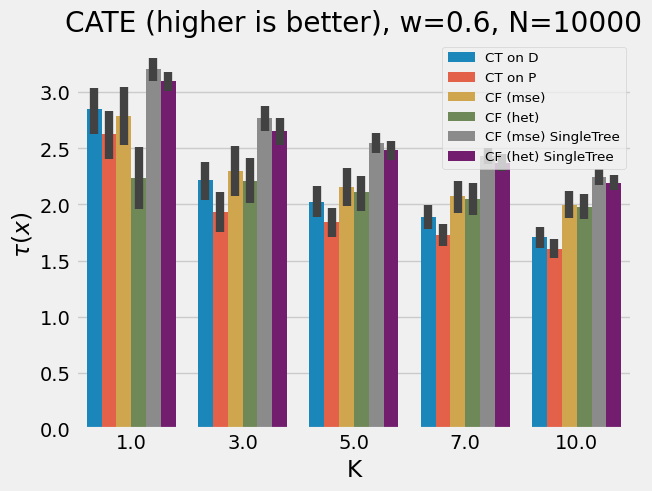

In [8]:
sns.barplot(x='K', y='t', hue='algorithm', data=scores_over_K)
plt.title(f"CATE (higher is better), w={str(default_w)}, N={str(N)}")
plt.ylabel(r"$\tau(x)$")
plt.legend(fontsize='x-small')
plt.show()

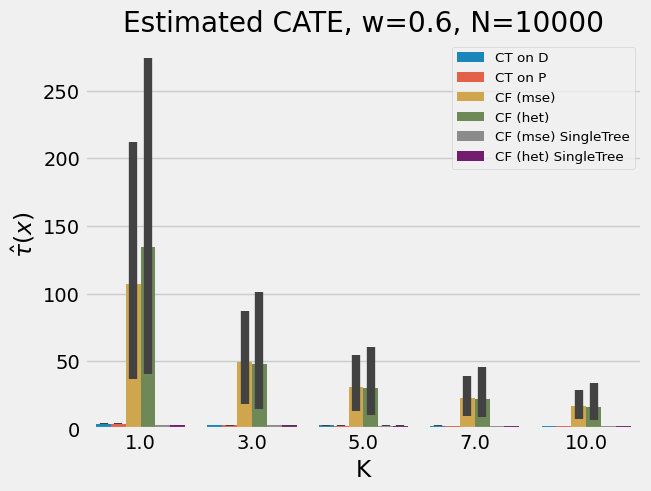

In [9]:
sns.barplot(x='K', y='t_est', hue='algorithm', data=scores_over_K)
plt.title(fr"Estimated CATE, w={str(default_w)}, N={str(N)}")
plt.ylabel(r"$\hat{{\tau}}(x)$")
plt.legend(fontsize='x-small')
plt.show()

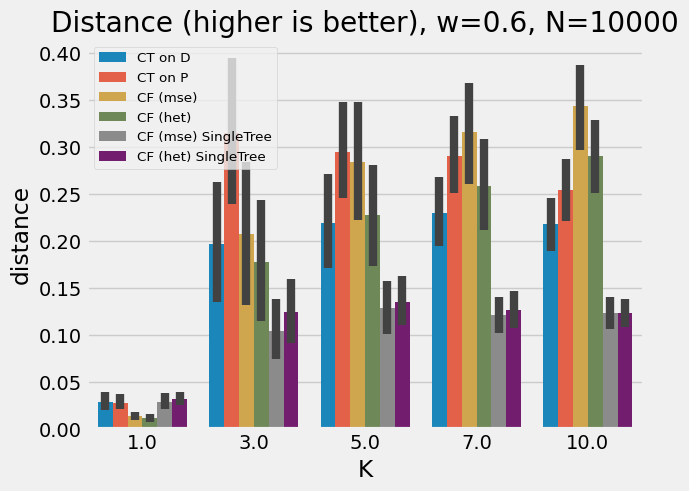

In [10]:
sns.barplot(x='K', y='distance', hue='algorithm', data=scores_over_K)
plt.title(f"Distance (higher is better), w={str(default_w)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

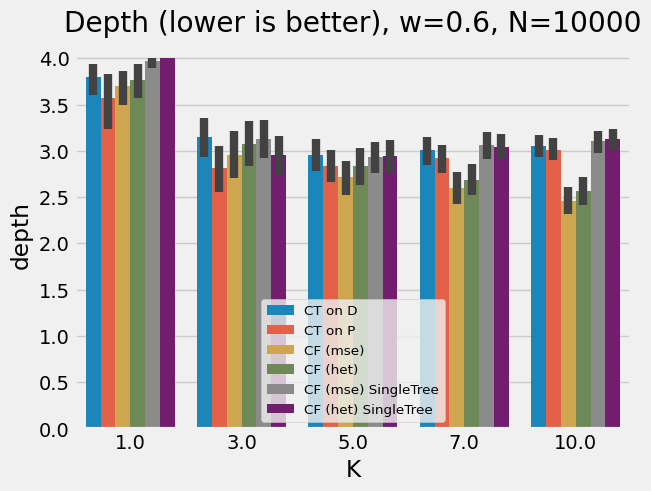

In [11]:
sns.barplot(x='K', y='depth', hue="algorithm", data=scores_over_K)
plt.title(f"Depth (lower is better), w={str(default_w)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

In [15]:
scores_over_K

,condition,t,t_est,distance,T0,T1,depth,norm_cate,score,algorithm,weight,K,execution_time
0,feature_2 <= -1.159 AND feature_0 > 0.499 AND ...,2.623,3.664,0.01,0.990952,4.654804,3,1.000000,0.604000,CT on D,NaN,1.0,NaN
1,feature_2 <= -1.16 AND feature_0 > 0.499 AND f...,2.623,3.664,0.01,0.990952,4.654804,3,1.000000,0.604000,CT on P,NaN,1.0,NaN
2,feature_0 > 0.41 AND feature_1 > 0.565 AND fea...,2.533,4.909,0.02,NaN,NaN,4,1.000000,0.608000,CF (mse),NaN,1.0,52.62
3,feature_0 > 0.277 AND feature_1 > 0.212 AND fe...,2.860,4.658,0.03,NaN,NaN,4,1.000000,0.612000,CF (het),NaN,1.0,58.74
4,feature_2 <= -1.159 AND feature_0 > 0.499 AND ...,2.623,3.664,0.01,0.990952,4.654804,3,1.000000,0.604000,CT on D,NaN,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4675,feature_0 > -0.228 AND feature_0 > 0.959 AND f...,2.103,1.932,0.01,NaN,NaN,4,0.878981,0.531389,CF (het) SingleTree,NaN,10.0,107.71
4676,feature_0 > -0.228 AND feature_0 > 0.959 AND f...,2.022,1.764,0.09,NaN,NaN,3,0.802548,0.517529,CF (het) SingleTree,NaN,10.0,107.71
4677,feature_0 > -0.228 AND feature_0 > 0.959 AND f...,1.836,1.703,0.08,NaN,NaN,4,0.774795,0.496877,CF (het) SingleTree,NaN,10.0,107.71
4678,feature_0 > -0.228 AND feature_0 <= 0.959 AND ...,2.345,1.633,0.03,NaN,NaN,4,0.742948,0.457769,CF (het) SingleTree,NaN,10.0,107.71


In [16]:
with open("scores_over_K.pkl", "wb") as f:
    pkl.dump(scores_over_K, f)